In [ ]:
from google.colab import files
upload=files.upload()

Saving iris.csv to iris (1).csv


In [ ]:
import sklearn.datasets as datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
from sklearn import tree
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
iris_df=pd.read_csv("iris.csv")
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
iris_df.isnull().any()
iris_df.dtypes


,0
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
species,object


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

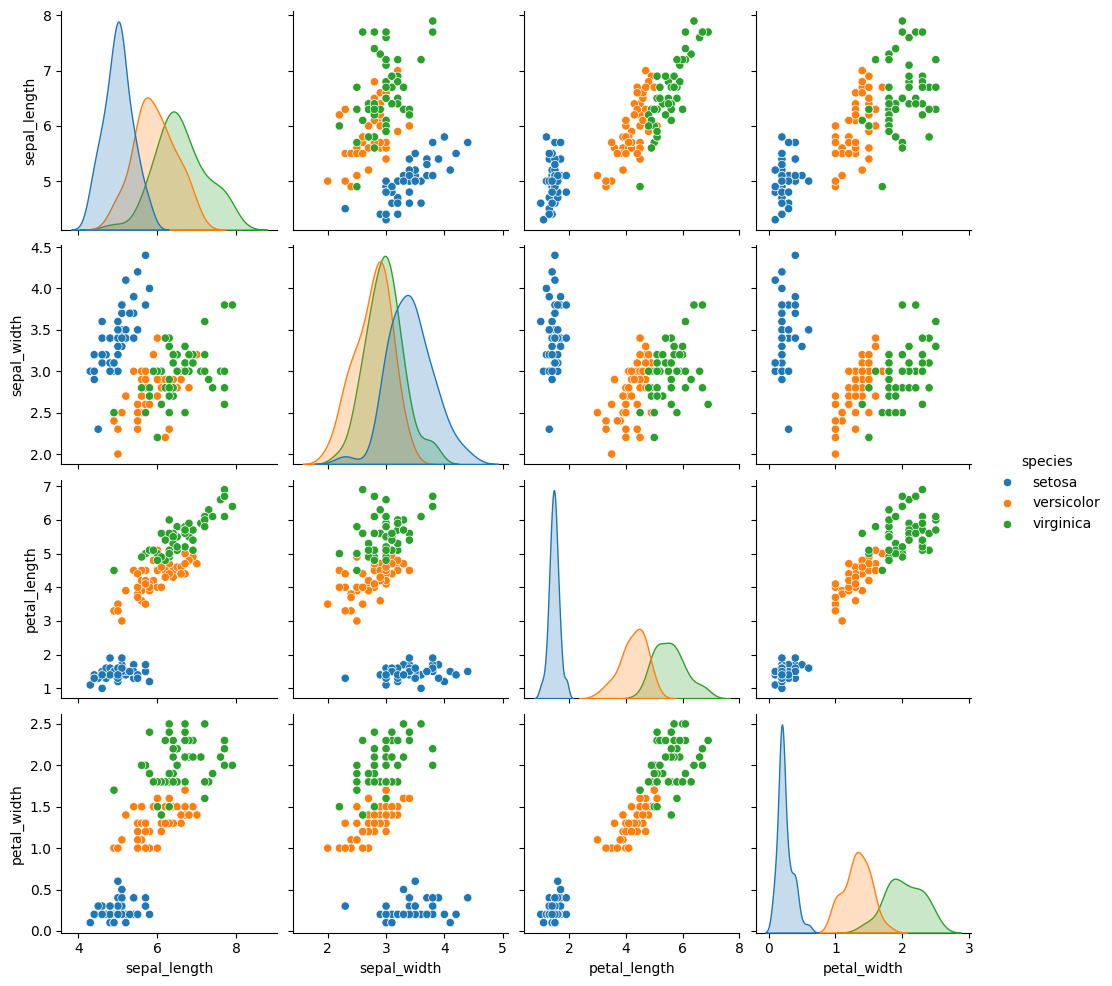

In [ ]:
sns.pairplot(iris_df, hue='species')
plt. savefig("exercise2a.png")
files. download("exercise2a.png")


In [ ]:
!pip install seaborn

In [ ]:
X = iris_df[['sepal_length', 'sepal_width',
             'petal_length', 'petal_width']].values
y = iris_df['species'].values

# Split the data (Added stratify=y to keep class proportions balanced)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.9,
    random_state=1,
    stratify=y
)
# Quick sanity check of the split sizes
print(f"Training shapes: {X_train.shape}, {y_train.shape}")
print(f"Testing shapes: {X_test.shape}, {y_test.shape}")


Training shapes: (135, 4), (135,)
Testing shapes: (15, 4), (15,)


In [ ]:
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)
prediction = clf.predict(X_test)
prediction


array(['versicolor', 'versicolor', 'virginica', 'setosa', 'versicolor',
       'setosa', 'setosa', 'virginica', 'versicolor', 'virginica',
       'setosa', 'versicolor', 'versicolor', 'virginica', 'setosa'],
      dtype=object)

In [ ]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         5
  versicolor       0.83      1.00      0.91         5
   virginica       1.00      0.80      0.89         5

    accuracy                           0.93        15
   macro avg       0.94      0.93      0.93        15
weighted avg       0.94      0.93      0.93        15



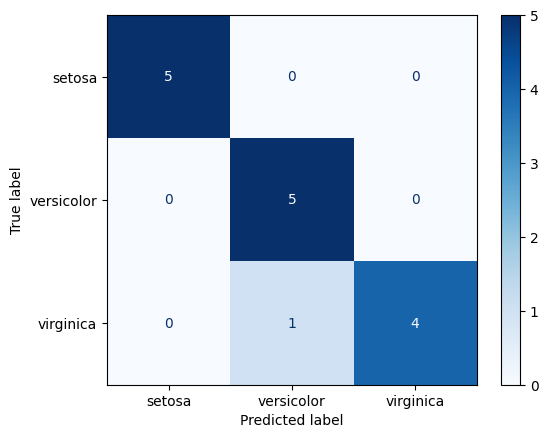

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from google.colab import files
import matplotlib.pyplot as plt
disp = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, cmap=plt.cm.Blues)
plt.savefig("exercise2b.png", bbox_inches='tight', dpi=300)
plt.show()
files.download("exercise2b.png")



In [ ]:
!pip install pydotplus
!apt-get install graphviz -y


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


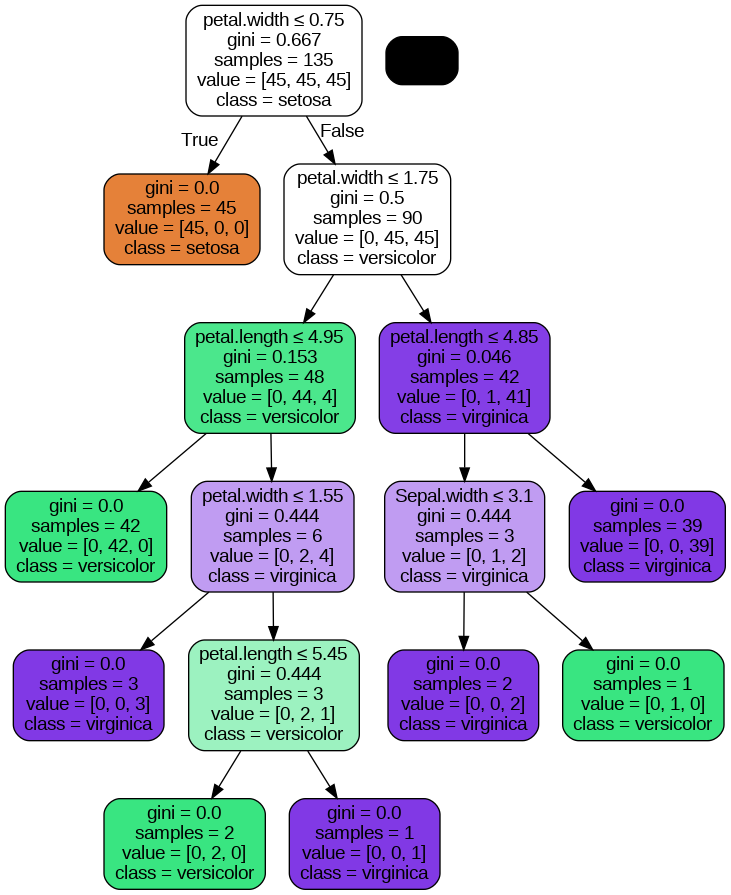

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from io import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
from google.colab import files
dot_data = StringIO()
export_graphviz(
    clf,
    out_file=dot_data,
    feature_names=['Sepal.length', 'Sepal.width', 'petal.length', 'petal.width'],
    class_names=clf.classes_.astype(str),
    filled=True,
    rounded=True,
    special_characters=True
)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png("exercise2c.png")
display(Image(graph.create_png()))
files.download("exercise2c.png")

In [ ]:
sepal_length = 4.8
sepal_width = 2.9
petal_length = 1.3
petal_width = 0.2
x = [[sepal_length, sepal_width, petal_length, petal_width]]
res = clf.predict(x)
print("The class predicted is --> " + str(res[0]))

The class predicted is --> setosa
